# Moving-Average Search with a 15% Trailing Stop

#### **MScFE 690 Capstone -Group 17843**

**Authors**: Edgar NAVA-edgar.nava@grovwm.com & Celestin NYANDWI-celestinnyandwi48@gmail.com

This experiment asks whether a SMA trading rule based on synthetic SVXY −1x prices
can achieve an annualized return above 10% with a maximum drawdown below 40%.
Returns include **US$0.005 commission per share** and **0.1% adverse slippage**
on every purchase and sale, for both the strategy and buy and hold.
Buy with **100% of available cash, including transaction costs,** at a bullish moving-average crossover.
Sell at a bearish crossover or a **15% trailing stop**, whichever occurs first.

Explore every integer pair with **d1 from 5 to 30**, **d2 from 15 to 200**, and
**d1 < d2**. A candidate qualifies only if, in **Development**, its:

- Annualized return (CAGR) is **strictly greater than 10%**.
- Maximum drawdown magnitude is **strictly less than 40%**
  (signed maximum drawdown **greater than −40%**).

Report how many pairs were tested and how many pass each condition and both
conditions together. The moving-average pair is selected from these results,
not specified in advance. If several pairs qualify, select the highest
Development Sharpe; break exact ties by the shorter d2, then the shorter d1.

Compare the selected model with buy and hold, first in Development and then
in Validation. Validation does not select, replace, or retune the model.

These rules were chosen after exploratory experiments. 

## 1. Settings and trading rules

Keep `SVXY_synth-ONEx.csv` in the same directory as this notebook.
Start each period with **$100,000 in cash**. 

For this experiment the rules are:

- When in cash, invest **all available cash, including transaction costs,**
  when SMA d1 crosses above SMA d2.
- Sell the entire position when SMA d1 crosses below SMA d2 or the Close is
  **15% or more below the trailing Close (the highest since entry)**, whichever occurs first.
- Initialize the peak at the entry Close. The stop is 85% of the running peak;
  it can move up but never down while that position is open.
- Evaluate the stop at the daily Close and execute the sale at that Close
  less slippage. The Close may be below the threshold. This is not an intraday
  stop order; the peak and stop remain based on the original Close.
- After selling, wait for a new bullish crossover on a later session.
  Do not re-enter merely because the fast average remains above the slow one.
- Equal averages do not trigger a trade. The first available pair of averages
  establishes their order; it is not itself a crossover.
- Use the same daily Close for the signal and the execution reference,
  with **0.1% adverse slippage**: buy at Close × 1.001 and sell at Close × 0.999.
  Deduct **US$0.005 per share** on every purchase and sale, with no minimum fee.
  Size purchases so execution value plus commission uses all available cash.
- Record costs immediately. A new purchase earns market returns only from the
  following close-to-close interval. Same-close signals remain an idealized assumption.
- Allow fractional units. Cash interest and the risk-free rate are zero.
  Use the supplied synthetic series as it stands, including its event adjustment.
  The per-share commission applies to units at the supplied synthetic price scale.
- Mark final open holdings at the last Close without forcing a sale.

Buy and hold invests $100,000 at the first Close of each period and holds
fixed units through the final Close. Its purchase includes the same commission
and slippage. Final holdings are marked at Close without a forced sale. It has no stop and is not subject to
the candidate-selection filters.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from IPython.display import display

%matplotlib inline

DATA_DIR = Path.cwd()
SVXY_FILE = DATA_DIR / "SVXY_synth-ONEx.csv"
D1_MIN, D1_MAX = 5, 30
D2_MIN, D2_MAX = 15, 200
TRAILING_STOP_PCT = 0.15
MIN_DEVELOPMENT_CAGR = 0.10  # Strict lower bound.
MAX_DRAWDOWN_LIMIT = 0.40  # Strict upper bound on drawdown magnitude.
INITIAL_CASH = 100_000.0
COMMISSION_PER_SHARE = 0.005  # USD per share, on each purchase and sale.
SLIPPAGE_PCT = 0.001  # 0.1% adverse execution on each purchase and sale.
SESSIONS_PER_YEAR = 252
ANNUAL_RISK_FREE_RATE = 0.0
DEVELOPMENT_START = pd.Timestamp("2011-10-04")
DEVELOPMENT_END = pd.Timestamp("2020-12-31")
VALIDATION_START = pd.Timestamp("2021-01-04")
VALIDATION_END = pd.Timestamp("2023-12-29")

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "figure.dpi": 120,
})
MODEL_COLOR = "#226a95"
BENCHMARK_COLOR = "#ce7b29"

if not (1 <= D1_MIN <= D1_MAX and 1 <= D2_MIN <= D2_MAX):
    raise ValueError("Each search range must contain positive integer windows.")
if not all(isinstance(x, int) for x in (D1_MIN, D1_MAX, D2_MIN, D2_MAX)):
    raise ValueError("Window limits must be integers.")
if not (0 < TRAILING_STOP_PCT < 1):
    raise ValueError("TRAILING_STOP_PCT must be between 0 and 1.")
if not (0 < MAX_DRAWDOWN_LIMIT < 1):
    raise ValueError("MAX_DRAWDOWN_LIMIT must be between 0 and 1.")
if not np.isfinite(MIN_DEVELOPMENT_CAGR) or MIN_DEVELOPMENT_CAGR <= -1:
    raise ValueError("MIN_DEVELOPMENT_CAGR must be finite and greater than -1.")
if not np.isfinite(COMMISSION_PER_SHARE) or COMMISSION_PER_SHARE < 0:
    raise ValueError("COMMISSION_PER_SHARE must be finite and nonnegative.")
if not np.isfinite(SLIPPAGE_PCT) or not (0 <= SLIPPAGE_PCT < 1):
    raise ValueError("SLIPPAGE_PCT must be between 0 (inclusive) and 1.")


## 2. Load the data and define the two periods

Development covers **4 October 2011–31 December 2020**. Validation covers
**4 January 2021–29 December 2023**. Exclude data from 2024 onward before any
price calculations. The search receives only the Development price series.

Each moving average uses a full trailing window. Include the initial cash days
in Development performance, so every candidate uses identical evaluation dates.
Only after selection, initialize the selected candidates' Validation averages
from earlier prices. Each Validation account starts with new cash and waits
for its first bullish crossover; no Development holdings or profits carry over.

In [2]:
raw = pd.read_csv(SVXY_FILE, usecols=["Date", "Close"], dtype="string")
raw["Date"] = pd.to_datetime(raw["Date"], format="%Y-%m-%d", errors="raise")
if raw["Date"].isna().any():
    raise ValueError("The input contains missing dates.")
raw = raw.loc[raw["Date"].between(DEVELOPMENT_START, VALIDATION_END)].copy()
if raw.empty or raw["Date"].duplicated().any():
    raise ValueError("The study data must be nonempty and have unique dates.")
raw["Close"] = pd.to_numeric(raw["Close"], errors="raise").astype(float)
if not (np.isfinite(raw["Close"]) & raw["Close"].gt(0)).all():
    raise ValueError("The study data contain invalid Close values.")
prices = raw.sort_values("Date").set_index("Date")
if (prices["Close"] * (1 - SLIPPAGE_PCT) <= COMMISSION_PER_SHARE).any():
    raise ValueError("Sale proceeds per share must exceed the commission.")

periods = {
    "Development": (DEVELOPMENT_START, DEVELOPMENT_END),
    "Validation": (VALIDATION_START, VALIDATION_END),
}
sample_rows = []
for label, (start, end) in periods.items():
    sample = prices.loc[start:end]
    if sample.empty or sample.index[0] != start or sample.index[-1] != end:
        raise ValueError(f"The input does not cover both {label} endpoints.")
    sample_rows.append({
        "Period": label, "First date": f"{sample.index[0]:%Y-%m-%d}",
        "Last date": f"{sample.index[-1]:%Y-%m-%d}", "Daily closes": len(sample),
    })
for row in sample_rows:
    print(f"{row['Period']}: {row['First date']} to {row['Last date']}; "
          f"{row['Daily closes']:,} daily closes.")

Development: 2011-10-04 to 2020-12-31; 2,327 daily closes.
Validation: 2021-01-04 to 2023-12-29; 753 daily closes.


## 3. Moving averages and crossover signals

Both averages include the current Close and require a full window. A bullish
crossover changes their order from SMA d1 below SMA d2 to SMA d1 above SMA d2;
a bearish crossover does the reverse. Equality carries forward the last known
order. There is no repeated buying while SMA d1 stays above SMA d2.

In [3]:
def add_crossover_signals(data, fast_window, slow_window):
    result = data[["Close"]].copy()
    result["SMA_fast"] = result["Close"].rolling(fast_window, min_periods=fast_window).mean()
    result["SMA_slow"] = result["Close"].rolling(slow_window, min_periods=slow_window).mean()
    difference = result["SMA_fast"] - result["SMA_slow"]
    # Carry the last known order across equality, but never backfill future values.
    order = np.sign(difference).replace(0.0, np.nan).ffill()
    previous_order = order.shift(1)
    result["Cross_up"] = order.eq(1) & previous_order.eq(-1)
    result["Cross_down"] = order.eq(-1) & previous_order.eq(1)
    return result

## 4. Portfolio accounting and performance measures

Mark existing holdings at today's Close before executing today's signal.
Deduct commission and adverse slippage on every trade. A new purchase earns
market returns only from the next close-to-close interval. All performance
measures below are net of these trading costs.

**Total profit** is final equity minus initial cash, including unrealized gains.
**Total return** is final equity divided by initial cash, minus one.
**Annualized return (CAGR)** uses elapsed calendar time and 365.25 days per year.
**Sharpe** uses daily excess returns, sample standard deviation, and 252 sessions
per year, including cash days. The first daily return compares the first
closing equity with initial cash, so any initial purchase costs are included.
Apply this convention to both strategies and the full search. An undefined
Sharpe is displayed as N/A.

**Drawdown** is equity divided by its running maximum, minus one, with the
running maximum starting at initial cash before any trading costs. **Maximum
drawdown** is the worst observation over the full period, including all trades
and cash intervals. Reset the equity peak only when a new period starts.
The 40% drawdown criterion filters historical Development results; it is not
a portfolio stop or a guarantee about Validation.

In [4]:
def finish_account(account, initial_cash):
    account = account.copy()
    account["Position_value"] = account["Units"] * account["Close"]
    account["Equity"] = account["Cash"] + account["Position_value"]
    account["Daily_return"] = account["Equity"].pct_change(fill_method=None)
    account.loc[account.index[0], "Daily_return"] = account["Equity"].iloc[0] / initial_cash - 1
    account["Drawdown"] = account["Equity"] / account["Equity"].cummax().clip(lower=initial_cash) - 1
    account["Exposure"] = account["Position_value"] / account["Equity"]
    return account


def run_crossover(data, initial_cash, trailing_stop_pct, commission_per_share, slippage_pct):
    if not (0 < trailing_stop_pct < 1):
        raise ValueError("trailing_stop_pct must be between 0 and 1.")
    cash, units, entry_price = float(initial_cash), 0.0, np.nan
    peak_close = np.nan
    records, orders = [], []
    for date, row in data.iterrows():
        price = float(row["Close"])
        equity_before_trade = cash + units * price
        side, reason, quantity = None, None, 0.0
        execution_price, commission, slippage_cost = np.nan, 0.0, 0.0
        trade_entry = entry_price
        trade_peak = max(peak_close, price) if units > 0 else np.nan
        trade_stop = trade_peak * (1 - trailing_stop_pct) if units > 0 else np.nan

        if units > 0:
            peak_close = trade_peak
            stop_hit = price <= trade_stop
            if stop_hit or bool(row["Cross_down"]):
                quantity = units
                execution_price = price * (1 - slippage_pct)
                commission = quantity * commission_per_share
                slippage_cost = quantity * price * slippage_pct
                cash += quantity * execution_price - commission
                units, side = 0.0, "SELL"
                reason = "Trailing stop" if stop_hit else "Bearish crossover"
                entry_price = peak_close = np.nan
            # An exit cannot be followed by another purchase on this same date.
        elif bool(row["Cross_up"]):
            execution_price = price * (1 + slippage_pct)
            quantity = cash / (execution_price + commission_per_share)
            commission = quantity * commission_per_share
            slippage_cost = quantity * price * slippage_pct
            units, cash, side = quantity, 0.0, "BUY"
            entry_price = trade_entry = execution_price + commission_per_share
            peak_close = trade_peak = price
            trade_stop = peak_close * (1 - trailing_stop_pct)
            reason = "Bullish crossover"

        if side is not None:
            orders.append({
                "Date": date, "Side": side, "Reason": reason,
                "Close": price, "Execution price": execution_price,
                "Units": quantity, "Trade value": quantity * execution_price,
                "Commission ($)": commission, "Slippage ($)": slippage_cost,
                "Entry cost per share": trade_entry, "Peak close": trade_peak,
                "Stop threshold": trade_stop,
                "Drawdown from peak at exit": price / trade_peak - 1 if side == "SELL" else np.nan,
                "Net position return at exit": (execution_price - commission_per_share) / trade_entry - 1
                    if side == "SELL" else np.nan,
                "Equity at trade": equity_before_trade,
            })
        records.append({
            "Date": date, "Close": price, "Cash": cash, "Units": units,
            "Entry_cost_per_share": entry_price,
            "Commission": commission, "Slippage_cost": slippage_cost,
            "Peak_close": peak_close,
            "Stop_threshold": peak_close * (1 - trailing_stop_pct) if units > 0 else np.nan,
        })
    account = finish_account(pd.DataFrame(records).set_index("Date"), initial_cash)
    order_columns = [
        "Date", "Side", "Reason", "Close", "Execution price", "Units", "Trade value",
        "Commission ($)", "Slippage ($)", "Entry cost per share", "Peak close",
        "Stop threshold", "Drawdown from peak at exit",
        "Net position return at exit", "Equity at trade",
    ]
    return account, pd.DataFrame(orders, columns=order_columns)


def run_buy_and_hold(data, initial_cash, commission_per_share, slippage_pct):
    account = data[["Close"]].copy()
    first_close = float(account["Close"].iloc[0])
    execution_price = first_close * (1 + slippage_pct)
    units = initial_cash / (execution_price + commission_per_share)
    account["Cash"] = 0.0
    account["Units"] = units
    account["Commission"] = 0.0
    account["Slippage_cost"] = 0.0
    account.loc[account.index[0], "Commission"] = units * commission_per_share
    account.loc[account.index[0], "Slippage_cost"] = units * first_close * slippage_pct
    return finish_account(account, initial_cash)


def performance(account, initial_cash):
    final = float(account["Equity"].iloc[-1])
    years = (account.index[-1] - account.index[0]).days / 365.25
    daily_rf = (1 + ANNUAL_RISK_FREE_RATE) ** (1 / SESSIONS_PER_YEAR) - 1
    excess = account["Daily_return"] - daily_rf
    volatility = float(excess.std(ddof=1))
    return pd.Series({
        "Initial equity ($)": initial_cash,
        "Final equity ($)": final,
        "Total profit ($)": final - initial_cash,
        "Total return": final / initial_cash - 1,
        "Annualized return (CAGR)": (final / initial_cash) ** (1 / years) - 1,
        "Sharpe ratio": np.sqrt(SESSIONS_PER_YEAR) * excess.mean() / volatility
            if volatility > 0 else np.nan,
        "Drawdown at final date": float(account["Drawdown"].iloc[-1]),
        "Maximum drawdown": float(account["Drawdown"].min()),
    })


def evaluate_selected_period(label, start, end, selected):
    data = prices.loc[start:end, ["Close"]].copy()
    history = prices.loc[:end, ["Close"]]
    benchmark = run_buy_and_hold(data, INITIAL_CASH, COMMISSION_PER_SHARE, SLIPPAGE_PCT)
    runs, metrics_by_method = {}, {}
    for _, candidate in selected.iterrows():
        rank = int(candidate["Development rank"])
        d1, d2 = int(candidate["d1"]), int(candidate["d2"])
        name = f"SMA {d1}/{d2}"
        signals = add_crossover_signals(history, d1, d2).loc[start:end]
        account, trades = run_crossover(
            signals, INITIAL_CASH, TRAILING_STOP_PCT, COMMISSION_PER_SHARE, SLIPPAGE_PCT
        )
        measures = performance(account, INITIAL_CASH)
        if label == "Development":
            if not np.allclose(
                [measures["Total profit ($)"], measures["Maximum drawdown"],
                 measures["Annualized return (CAGR)"], measures["Sharpe ratio"]],
                [candidate["Development total profit ($)"],
                 candidate["Development maximum drawdown"],
                 candidate["Development CAGR"], candidate["Development Sharpe"]],
                rtol=1e-10, atol=1e-10,
            ):
                raise ValueError("Detailed Development results do not match the search.")
            if not (measures["Maximum drawdown"] > -MAX_DRAWDOWN_LIMIT
                    and measures["Annualized return (CAGR)"] > MIN_DEVELOPMENT_CAGR):
                raise ValueError("Selected candidate fails a Development selection condition.")
        runs[name] = {"account": account, "trades": trades, "rank": rank,
                      "d1": d1, "d2": d2}
        metrics_by_method[name] = measures
    metrics_by_method["Buy and hold"] = performance(benchmark, INITIAL_CASH)
    return {"label": label, "data": data, "runs": runs, "benchmark": benchmark,
            "metrics": pd.DataFrame(metrics_by_method)}

In [5]:
TABLE_STYLES = [
    {"selector": "caption", "props": [("font-size", "17px"), ("font-weight", "bold"),
                                        ("text-align", "left"), ("padding", "10px 0")]},
    {"selector": "th", "props": [("background-color", "#255c80"), ("color", "white"),
                                   ("padding", "9px 12px"), ("text-align", "left")]},
    {"selector": "td", "props": [("padding", "9px 12px"), ("text-align", "right")]},
    {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#edf3f7")]},
]


def show_metrics(result):
    table = result["metrics"].copy().astype(object)
    for metric in table.index:
        if "($)" in metric:
            table.loc[metric] = result["metrics"].loc[metric].map(lambda x: f"${x:,.2f}")
        elif metric == "Sharpe ratio":
            table.loc[metric] = result["metrics"].loc[metric].map(
                lambda x: f"{x:.3f}" if np.isfinite(x) else "N/A")
        else:
            table.loc[metric] = result["metrics"].loc[metric].map(lambda x: f"{x:.2%}")
    display(table.style.set_caption(
        f"{result['label']} — Selected Model vs. Buy and Hold | Net of Trading Costs"
    ).set_table_styles(TABLE_STYLES))
    for name, run in result["runs"].items():
        trades = run["trades"]
        buys = int(trades["Side"].eq("BUY").sum())
        sells = int(trades["Side"].eq("SELL").sum())
        stops = int(trades["Reason"].eq("Trailing stop").sum())
        position = "invested" if run["account"]["Units"].iloc[-1] > 0 else "cash"
        print(f"{name}: {buys} purchases, {sells} sales, {stops} trailing-stop exits; "
              f"final position: {position}.")


def plot_comparison(result):
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2.2, 1]}, constrained_layout=True)
    series = [(name, run["account"], MODEL_COLOR)
              for name, run in result["runs"].items()]
    series.append(("Buy and hold", result["benchmark"], BENCHMARK_COLOR))
    for name, account, color in series:
        axes[0].plot(account.index, account["Equity"], color=color, lw=1.5,
                     label=f"{name} — ${account['Equity'].iloc[-1]:,.0f}")
        axes[1].plot(account.index, account["Drawdown"], color=color, lw=1.1)
    data = result["data"]
    axes[0].set_title(
        f"{result['label']} — Selected Model vs. Buy and Hold | Net of Trading Costs\n"
        f"{data.index[0]:%Y-%m-%d} to {data.index[-1]:%Y-%m-%d} | "
        f"Strategy trailing stop: {TRAILING_STOP_PCT:.0%}", loc="left", pad=12)
    axes[0].axhline(INITIAL_CASH, color="#777777", ls="--", lw=0.8)
    axes[0].set_ylabel("Portfolio equity ($)")
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    axes[0].legend(loc="upper left", ncol=2, fontsize=9, frameon=False)
    axes[1].set_ylabel("Drawdown")
    axes[1].set_xlabel("Date")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    axes[1].axhline(0, color="#777777", lw=0.7)
    for ax in axes:
        ax.grid(axis="y", alpha=0.2)
        ax.margins(x=0.01)
    plt.show()


def plot_metric_comparison(result):
    metrics = result["metrics"]
    methods = list(metrics.columns)
    panels = [
        ("Total return", "Total return", True),
        ("Annualized return (CAGR)", "Annualized return (CAGR)", True),
        ("Sharpe ratio", "Sharpe ratio", False),
        ("Maximum drawdown", "Maximum drawdown", True),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), constrained_layout=True)
    fig.suptitle(f"{result['label']} — Performance Comparison | Net of Trading Costs", fontsize=15)
    for ax, (metric, title, is_percent) in zip(axes.flat, panels):
        values = metrics.loc[metric].to_numpy(dtype=float)
        bars = ax.bar(methods, values, color=[MODEL_COLOR, BENCHMARK_COLOR], width=0.55)
        ax.set_title(title, loc="left", fontsize=12)
        ax.axhline(0, color="#777777", lw=0.8)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
        if is_percent:
            ax.yaxis.set_major_formatter(PercentFormatter(1))
        labels = [f"{value:.2%}" if is_percent else f"{value:.3f}" for value in values]
        ax.bar_label(bars, labels=labels, padding=5, fontsize=10)
        ax.margins(y=0.25)
    plt.show()


## 5. Explore all moving-average pairs in Development

Test every pair in the specified ranges using 100% entry allocation and the
15% trailing stop. Include commission and slippage in every candidate
before applying the selection filters. Count the candidates with CAGR above 10%, those with
drawdown magnitude below 40%, and the intersection of these two conditions.
The individual counts refer to the full grid and are not added together.

Keep the complete results in `search_results`. Display all qualifying pairs
in the following section. Use Development Sharpe only to select one model
if more than one pair meets both conditions.

In [6]:
candidates = pd.DataFrame(
    [(d1, d2)
     for d1 in range(D1_MIN, D1_MAX + 1)
     for d2 in range(D2_MIN, D2_MAX + 1)
     if d1 < d2], columns=["d1", "d2"],
)
if candidates.empty:
    raise ValueError("The search ranges contain no pair with d1 < d2.")


def development_grid(data, pairs):
    """Return Development Sharpe, profit, and drawdown for all parameter pairs."""
    windows = sorted(set(pairs["d1"]) | set(pairs["d2"]))
    averages = pd.DataFrame({
        window: data["Close"].rolling(window, min_periods=window).mean()
        for window in windows
    })
    window_column = {window: i for i, window in enumerate(windows)}
    fast_columns = pairs["d1"].map(window_column).to_numpy(dtype=int)
    slow_columns = pairs["d2"].map(window_column).to_numpy(dtype=int)
    ma_values = averages.to_numpy()
    close_values = data["Close"].to_numpy()
    size = len(pairs)
    cash = np.full(size, INITIAL_CASH, dtype=float)
    units = np.zeros(size)
    peak_close = np.full(size, np.nan)
    previous_order = np.zeros(size, dtype=np.int8)
    equity_peak = np.full(size, INITIAL_CASH, dtype=float)
    max_drawdown = np.zeros(size)
    previous_equity = np.full(size, INITIAL_CASH, dtype=float)
    mean_excess = np.zeros(size)
    sum_squared_deviations = np.zeros(size)
    return_count = 0
    daily_rf = (1 + ANNUAL_RISK_FREE_RATE) ** (1 / SESSIONS_PER_YEAR) - 1
    for i, price in enumerate(close_values):
        difference = ma_values[i, fast_columns] - ma_values[i, slow_columns]
        current_order = previous_order.copy()
        current_order[difference > 0] = 1
        current_order[difference < 0] = -1
        cross_up = (previous_order == -1) & (current_order == 1)
        cross_down = (previous_order == 1) & (current_order == -1)
        previous_order = current_order
        holding = units > 0
        peak_close[holding] = np.maximum(peak_close[holding], price)
        stop_hit = holding & (price <= peak_close * (1 - TRAILING_STOP_PCT))
        sell = holding & (stop_hit | cross_down)
        buy = (~holding) & cross_up
        cash[sell] += units[sell] * (price * (1 - SLIPPAGE_PCT) - COMMISSION_PER_SHARE)
        units[sell] = 0.0
        peak_close[sell] = np.nan
        units[buy] = cash[buy] / (price * (1 + SLIPPAGE_PCT) + COMMISSION_PER_SHARE)
        cash[buy] = 0.0
        peak_close[buy] = price
        equity = cash + units * price
        equity_peak = np.maximum(equity_peak, equity)
        max_drawdown = np.minimum(max_drawdown, equity / equity_peak - 1)
        # Start from initial cash, including any first-day costs and all cash days.
        excess = equity / previous_equity - 1 - daily_rf
        return_count += 1
        delta = excess - mean_excess
        mean_excess += delta / return_count
        sum_squared_deviations += delta * (excess - mean_excess)
        previous_equity = equity.copy()
    sharpe = np.full(size, np.nan)
    if return_count > 1:
        volatility = np.sqrt(sum_squared_deviations / (return_count - 1))
        np.divide(np.sqrt(SESSIONS_PER_YEAR) * mean_excess, volatility,
                  out=sharpe, where=volatility > 0)
    result = pairs.copy()
    years = (data.index[-1] - data.index[0]).days / 365.25
    result["Development CAGR"] = (equity / INITIAL_CASH) ** (1 / years) - 1
    result["Development Sharpe"] = sharpe
    result["Development final equity ($)"] = equity
    result["Development total profit ($)"] = equity - INITIAL_CASH
    result["Development total return"] = equity / INITIAL_CASH - 1
    result["Development maximum drawdown"] = max_drawdown
    return result


def select_candidates(results):
    cagr_pass = results["Development CAGR"].gt(MIN_DEVELOPMENT_CAGR)
    drawdown_pass = results["Development maximum drawdown"].gt(-MAX_DRAWDOWN_LIMIT)
    qualified = results.loc[cagr_pass & drawdown_pass].sort_values(
        ["Development Sharpe", "d2", "d1"], ascending=[False, True, True],
        na_position="last",
    ).reset_index(drop=True)
    selected = qualified.head(1).copy()
    selected.insert(0, "Development rank", np.arange(1, len(selected) + 1))
    summary = pd.DataFrame({
        "Selection check": [
            "Moving-average pairs evaluated",
            f"CAGR > {MIN_DEVELOPMENT_CAGR:.0%}",
            f"Maximum drawdown magnitude < {MAX_DRAWDOWN_LIMIT:.0%}",
            "Meet both conditions",
        ],
        "Candidates": [len(results), int(cagr_pass.sum()), int(drawdown_pass.sum()),
                       len(qualified)],
    })
    return qualified, selected, summary


development_prices = prices.loc[DEVELOPMENT_START:DEVELOPMENT_END, ["Close"]].copy()
search_results = development_grid(development_prices, candidates)
qualifying_candidates, selected_candidates, search_summary = select_candidates(search_results)
display(search_summary.style.hide(axis="index").format({"Candidates": "{:,.0f}"})
        .set_caption("Development Search — Candidate Counts after Trading Costs")
        .set_table_styles(TABLE_STYLES))


Selection check,Candidates
Moving-average pairs evaluated,"4,700"
CAGR > 10%,14
Maximum drawdown magnitude < 40%,415
Meet both conditions,1


## 6. Qualifying candidates and selected model

The following table contains every candidate that meets both Development
conditions. Freeze the selected model before evaluating Validation; its
parameters and trading rules stay unchanged.

In [7]:
development = validation = None
if qualifying_candidates.empty:
    print("No candidate meets both Development conditions. No model is selected.")
else:
    columns = ["d1", "d2", "Development CAGR", "Development maximum drawdown",
               "Development Sharpe", "Development total return"]
    display(qualifying_candidates[columns].style.hide(axis="index").format({
        "Development CAGR": "{:.2%}", "Development maximum drawdown": "{:.2%}",
        "Development Sharpe": "{:.3f}", "Development total return": "{:.2%}",
    }).set_caption("Candidates Meeting Both Development Conditions after Trading Costs")
    .set_table_styles(TABLE_STYLES))
    chosen = selected_candidates.iloc[0]
    name = f"SMA {int(chosen['d1'])}/{int(chosen['d2'])}"
    if len(qualifying_candidates) == 1:
        print(f"Of {len(search_results):,} pairs evaluated, {name} is the only candidate "
              "that meets both conditions.")
    else:
        print(f"{len(qualifying_candidates):,} candidates meet both conditions. "
              f"Selected {name} by Development Sharpe.")
    print(f"Development CAGR: {chosen['Development CAGR']:.2%}; "
          f"maximum drawdown: {chosen['Development maximum drawdown']:.2%}; "
          f"Sharpe ratio: {chosen['Development Sharpe']:.3f}.")

d1,d2,Development CAGR,Development maximum drawdown,Development Sharpe,Development total return
5,87,11.15%,-39.65%,0.486,165.63%


Of 4,700 pairs evaluated, SMA 5/87 is the only candidate that meets both conditions.
Development CAGR: 11.15%; maximum drawdown: -39.65%; Sharpe ratio: 0.486.


## 7. Development — selected model versus buy and hold

Compare the model selected by the search with buy and hold on identical dates.
Each strategy starts with $100,000 before costs. All results include the
same commission and slippage. The table reports profit, total and annualized
return, Sharpe, and drawdown. The charts show portfolio equity, drawdown through
time, and the main performance measures.

In [8]:
if not selected_candidates.empty:
    development = evaluate_selected_period(
        "Development", DEVELOPMENT_START, DEVELOPMENT_END, selected_candidates
    )
    show_metrics(development)

,SMA 5/87,Buy and hold
Initial equity ($),"$100,000.00","$100,000.00"
Final equity ($),"$265,631.86","$710,137.84"
Total profit ($),"$165,631.86","$610,137.84"
Total return,165.63%,610.14%
Annualized return (CAGR),11.15%,23.63%
Sharpe ratio,0.486,0.673
Drawdown at final date,-24.54%,-74.01%
Maximum drawdown,-39.65%,-87.91%


SMA 5/87: 27 purchases, 26 sales, 18 trailing-stop exits; final position: invested.


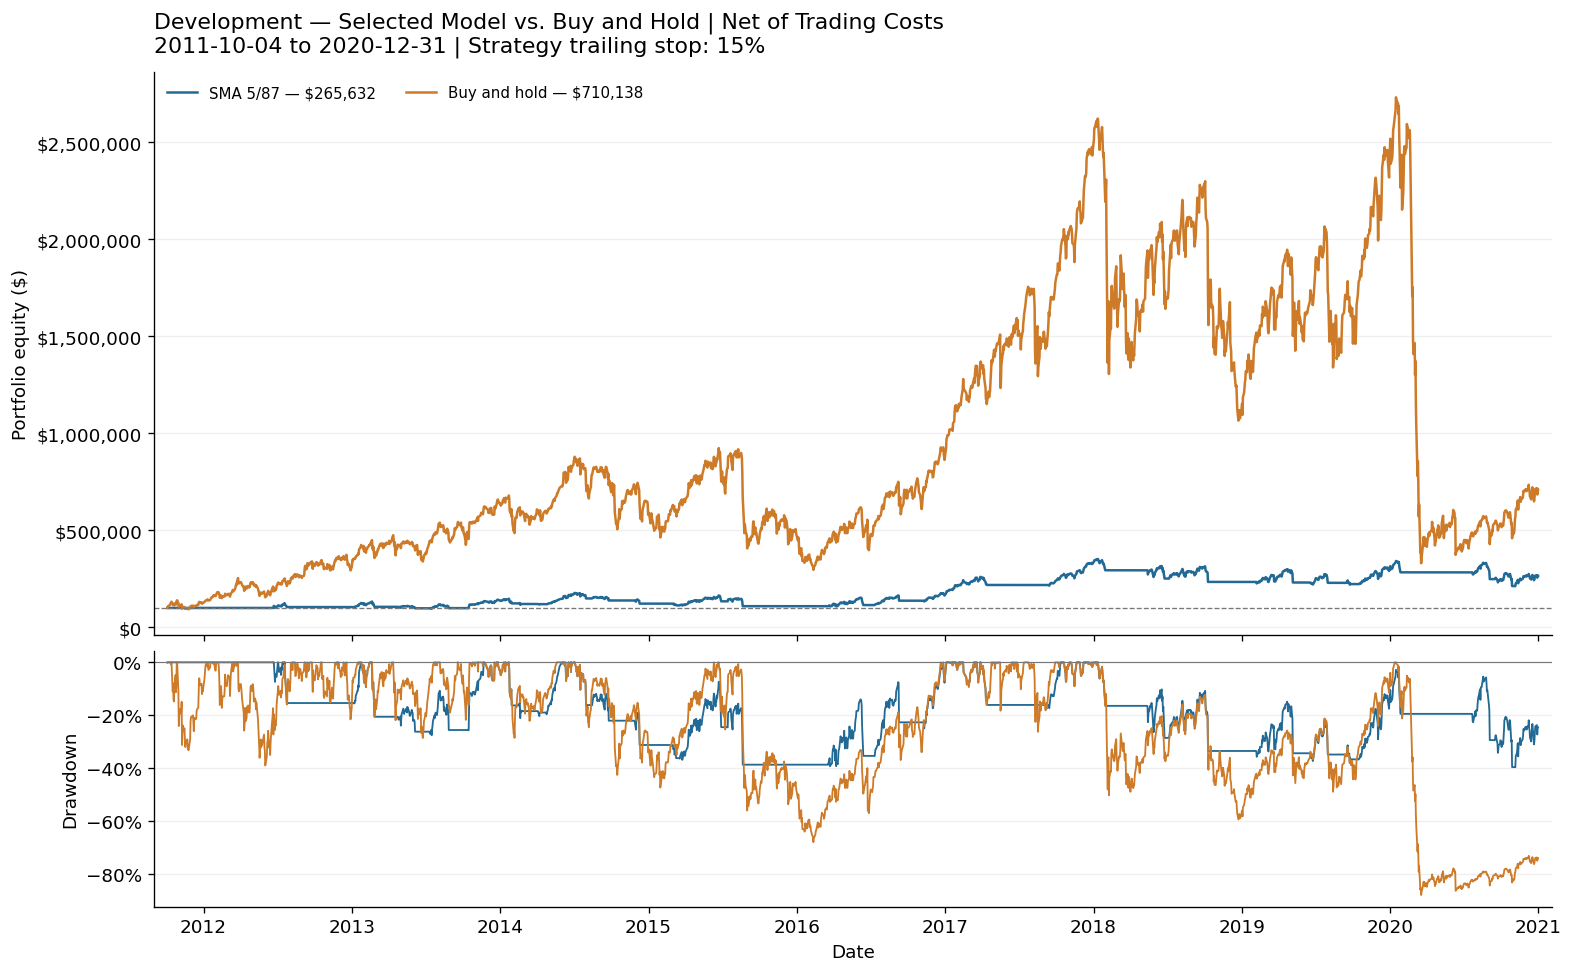

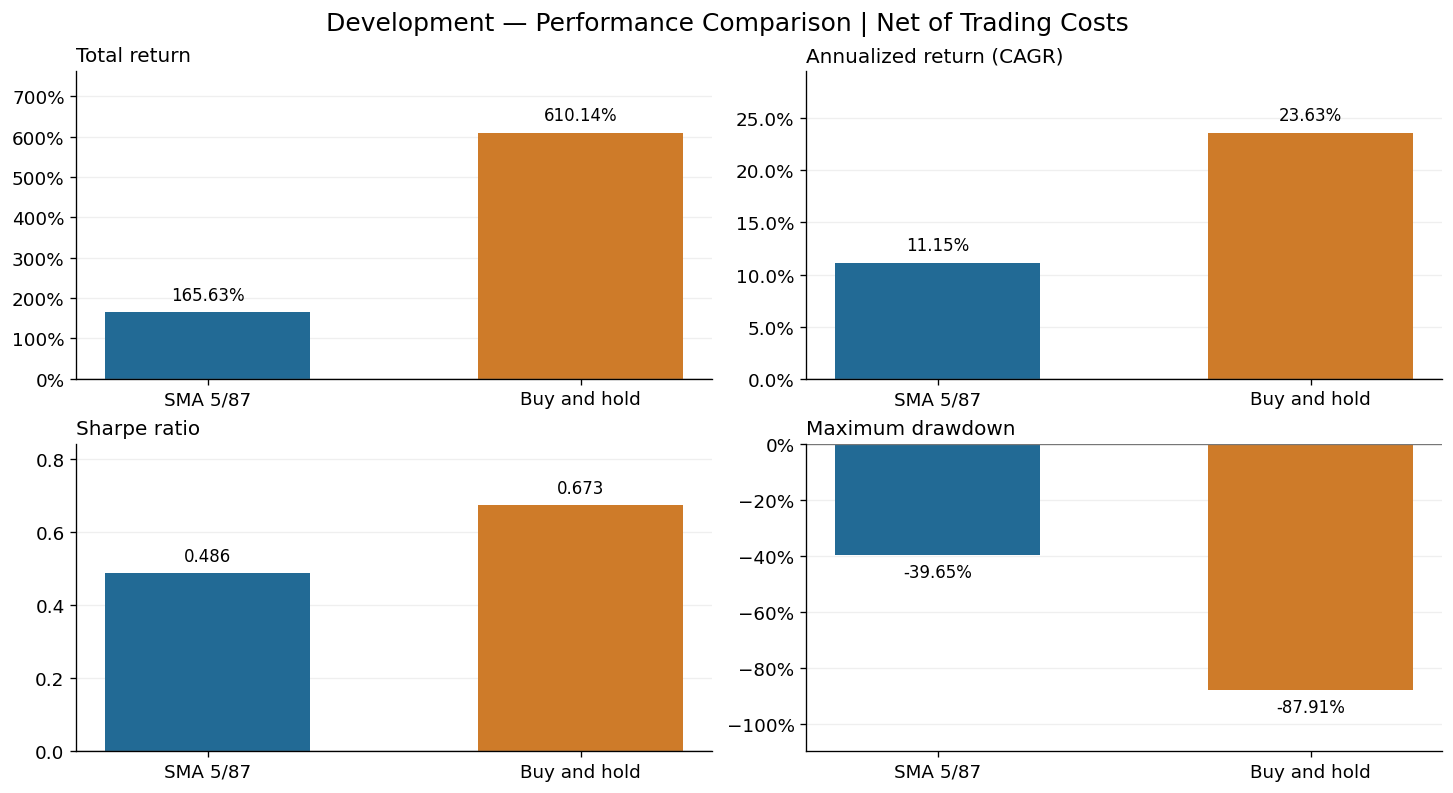

In [9]:
if development is not None:
    plot_comparison(development)
    plot_metric_comparison(development)

## 8. Validation — the same model versus buy and hold

Apply the selected moving averages, 100% entry allocation, and 15% trailing
stop without changing them. Apply the same commission and slippage.
Start each strategy with a fresh $100,000 account before costs.
Past prices may initialize the moving averages, but no holdings or profits
carry over from Development.

Report the full results, including any drawdown worse than the Development
selection threshold. Validation is an evaluation of the selected model,
not another search.

In [10]:
if not selected_candidates.empty:
    validation = evaluate_selected_period(
        "Validation", VALIDATION_START, VALIDATION_END, selected_candidates
    )
    show_metrics(validation)

,SMA 5/87,Buy and hold
Initial equity ($),"$100,000.00","$100,000.00"
Final equity ($),"$138,578.96","$471,074.00"
Total profit ($),"$38,578.96","$371,074.00"
Total return,38.58%,371.07%
Annualized return (CAGR),11.56%,68.17%
Sharpe ratio,0.490,1.116
Drawdown at final date,-3.56%,-0.21%
Maximum drawdown,-47.38%,-56.58%


SMA 5/87: 9 purchases, 8 sales, 6 trailing-stop exits; final position: invested.


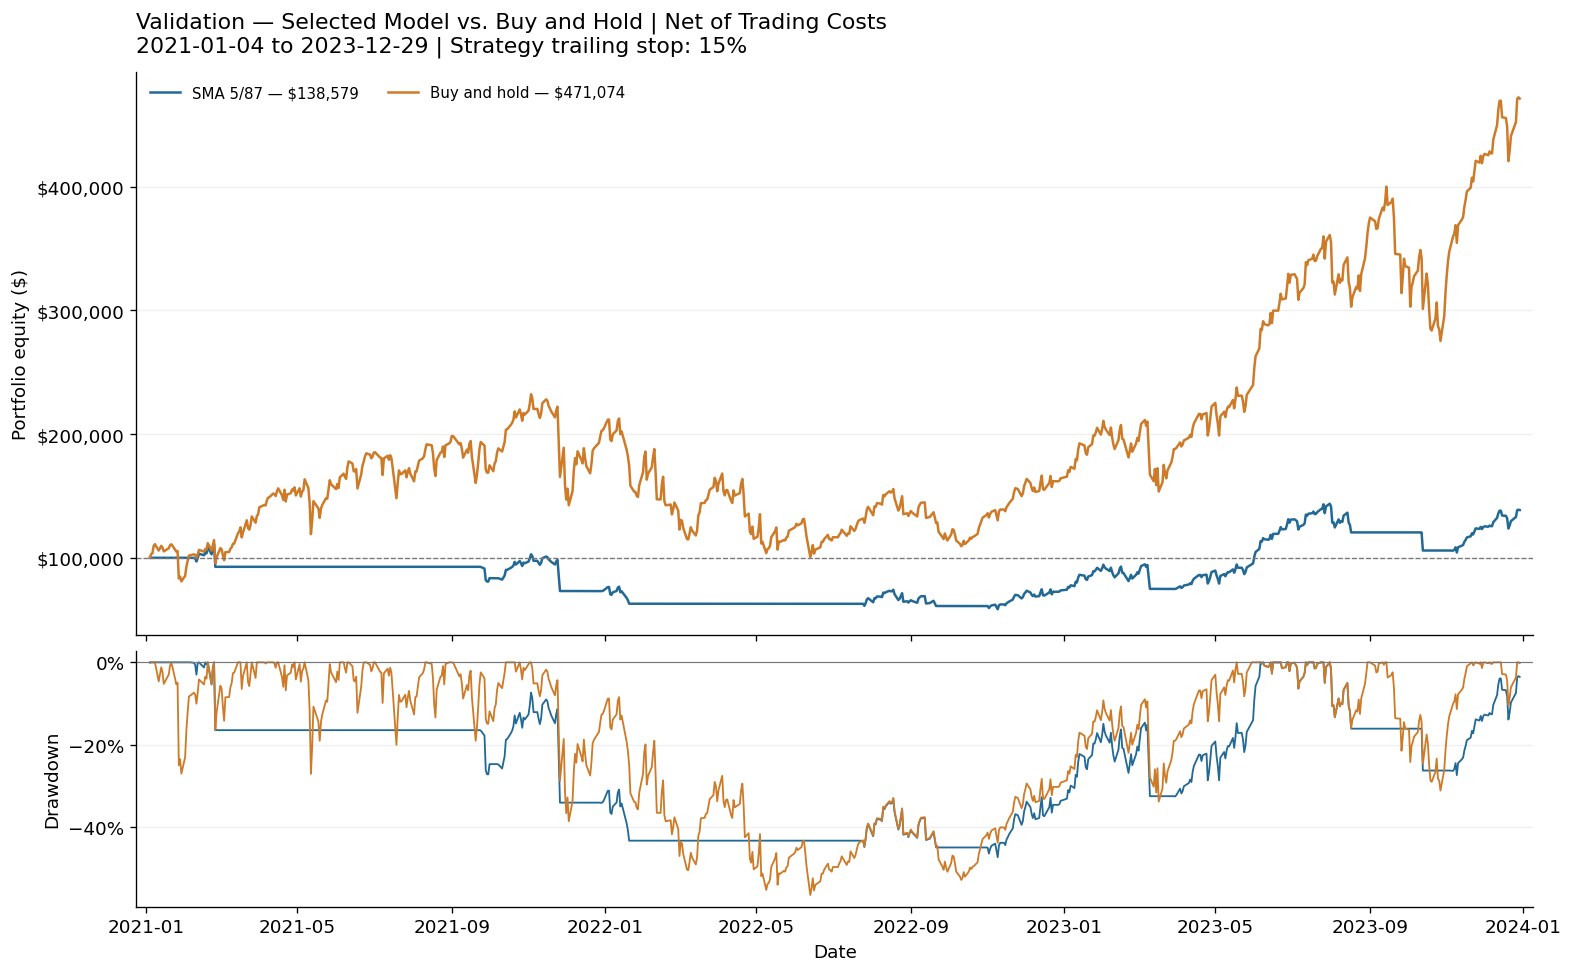

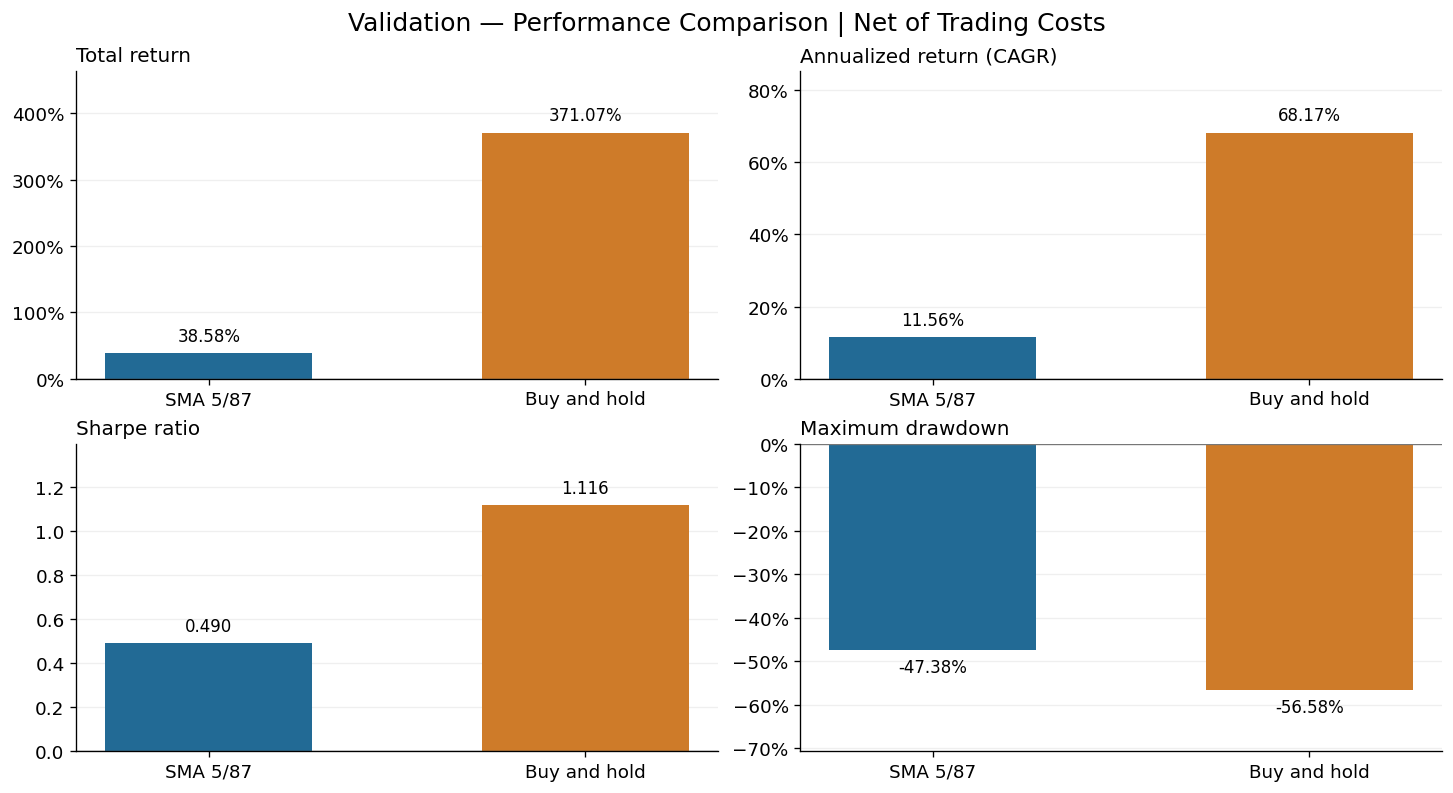

In [11]:
if validation is not None:
    plot_comparison(validation)
    plot_metric_comparison(validation)